<a href="https://colab.research.google.com/github/Kajalsah1/2418104_kajalsah/blob/main/2418104_KajalSah_Classification_Task_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h5>FINAL PORTFOLIO ASSESSMENT</h5>

<h5>Concept and Technologies of AI</h5>

<h5>CLASSIFICATION TASK ON COUNTRIES CO2 EMMISSIONS, ENERGY CONSUMPTIONS</h5>

In [ ]:
#all necessary libraries imported:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import warnings

# Load dataset
df = pd.read_csv("energy.csv")


In [ ]:
#The number of rows and columns in this dataset:
print("The shape of the energy dataset is:", df.shape)


The shape of the energy dataset is: (55440, 11)


In [ ]:
#List of names of columns:
print("\nThe columns in this dataset is:\n", df.columns)


The columns in this dataset is:
 Index(['Unnamed: 0', 'Country', 'Energy_type', 'Year', 'Energy_consumption',
       'Energy_production', 'GDP', 'Population', 'Energy_intensity_per_capita',
       'Energy_intensity_by_GDP', 'CO2_emission'],
      dtype='object')


In [ ]:
print("\nThe first 5 rows are:")
(df.head())


The first 5 rows are:


,Unnamed: 0,Country,Energy_type,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
0,0,World,all_energy_types,1980,292.899790,296.337228,27770.910281,4.298127e+06,68.145921,10.547,4946.627130
1,1,World,coal,1980,78.656134,80.114194,27770.910281,4.298127e+06,68.145921,10.547,1409.790188
2,2,World,natural_gas,1980,53.865223,54.761046,27770.910281,4.298127e+06,68.145921,10.547,1081.593377
3,3,World,petroleum_n_other_liquids,1980,132.064019,133.111109,27770.910281,4.298127e+06,68.145921,10.547,2455.243565
4,4,World,nuclear,1980,7.575700,7.575700,27770.910281,4.298127e+06,68.145921,10.547,0.000000


In [ ]:
print("\nThe summary statistics of dataset is:")
(df.describe())


The summary statistics of dataset is:


,Unnamed: 0,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
count,55440.000000,55440.0000,44287.000000,4.428900e+04,40026.000000,4.601400e+04,50358.000000,50358.000000,51614.000000
mean,27719.500000,1999.5000,1.537811,1.532700e+00,827.144126,6.263020e+04,71.898914,3.695104,78.800082
std,16004.293799,11.5435,15.456596,1.530356e+01,5981.703144,4.562088e+05,113.728738,4.590735,902.221463
min,0.000000,1980.0000,-0.163438,-1.000000e-39,0.124958,1.147100e+01,0.000000,0.000000,-0.005130
25%,13859.750000,1989.7500,0.000000,0.000000e+00,9.737780,1.141950e+03,3.799939,0.899446,0.000000
50%,27719.500000,1999.5000,0.018381,5.121971e-04,47.757100,6.157680e+03,29.779260,2.987593,0.000000
75%,41579.250000,2009.2500,0.209422,1.125410e-01,263.687100,2.004290e+04,95.523627,4.969454,4.318822
max,55439.000000,2019.0000,601.040490,6.115090e+02,127690.247059,7.714631e+06,1139.320598,166.913605,35584.933498


In [ ]:
print("\nThe total number of missing values are:")
print(df.isnull().sum())


The total number of missing values are:
Unnamed: 0                         0
Country                            0
Energy_type                        0
Year                               0
Energy_consumption             11153
Energy_production              11151
GDP                            15414
Population                      9426
Energy_intensity_per_capita     5082
Energy_intensity_by_GDP         5082
CO2_emission                    3826
dtype: int64


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("\nNumeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['Unnamed: 0', 'Year', 'Energy_consumption', 'Energy_production', 'GDP', 'Population', 'Energy_intensity_per_capita', 'Energy_intensity_by_GDP', 'CO2_emission']
Categorical columns: ['Country', 'Energy_type']


<h5>Summary Statistics</h5>

In [ ]:
# Numeric columns
numeric_cols = [
    'Year',
    'Energy_consumption',
    'Energy_production',
    'GDP',
    'Population',
    'Energy_intensity_per_capita',
    'Energy_intensity_by_GDP',
    'CO2_emission'
]

# Summary statistics
summary_stats = df[numeric_cols].describe()

# Range calculation
range_stats = df[numeric_cols].max() - df[numeric_cols].min()

print("SUMMARY STATISTICS:\n", summary_stats)
print("\nRANGE OF EACH VARIABLE:\n", range_stats)

SUMMARY STATISTICS:
              Year  Energy_consumption  Energy_production            GDP  \
count  55440.0000        44287.000000       4.428900e+04   40026.000000   
mean    1999.5000            1.537811       1.532700e+00     827.144126   
std       11.5435           15.456596       1.530356e+01    5981.703144   
min     1980.0000           -0.163438      -1.000000e-39       0.124958   
25%     1989.7500            0.000000       0.000000e+00       9.737780   
50%     1999.5000            0.018381       5.121971e-04      47.757100   
75%     2009.2500            0.209422       1.125410e-01     263.687100   
max     2019.0000          601.040490       6.115090e+02  127690.247059   

         Population  Energy_intensity_per_capita  Energy_intensity_by_GDP  \
count  4.601400e+04                 50358.000000             50358.000000   
mean   6.263020e+04                    71.898914                 3.695104   
std    4.562088e+05                   113.728738                 4.59073

In [ ]:
# Fill numeric columns with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Filled numeric NaNs with median")

# Fill categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Filled categorical NaNs with mode")


Filled numeric NaNs with median
Filled categorical NaNs with mode


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("\n SUMMARY STATISTICS AFTER")
print(df[num_cols].describe())


 SUMMARY STATISTICS AFTER
         Unnamed: 0        Year  Energy_consumption  Energy_production  \
count  55440.000000  55440.0000        55440.000000       5.544000e+04   
mean   27719.500000   1999.5000            1.232143       1.224521e+00   
std    16004.293799     11.5435           13.828056       1.369194e+01   
min        0.000000   1980.0000           -0.163438      -1.000000e-39   
25%    13859.750000   1989.7500            0.000848       0.000000e+00   
50%    27719.500000   1999.5000            0.018381       5.121971e-04   
75%    41579.250000   2009.2500            0.118580       4.493183e-02   
max    55439.000000   2019.0000          601.040490       6.115090e+02   

                 GDP    Population  Energy_intensity_per_capita  \
count   55440.000000  5.544000e+04                 55440.000000   
mean      610.450915  5.302865e+04                    68.037945   
std      5094.544942  4.161609e+05                   109.070094   
min         0.124958  1.147100e+01    

In [ ]:
#Checking for any duplicate values:
duplicate_values = df.duplicated().sum()
print(f"\nDuplicates found: {duplicate_values}")


Duplicates found: 0


In [ ]:
# Create binary class from CO2 emission
median_co2 = df["CO2_emission"].median()

df["CO2_class"] = (df["CO2_emission"] > median_co2).astype(int)

print(df["CO2_class"].value_counts())


CO2_class
0    30783
1    24657
Name: count, dtype: int64


<b>Intrepretation:</b>
<b>The dataset does not contain a direct class label.
So, the CO2 emission values were converted into a binary class using the median threshold,
where values above the median were labeled as high emission (1) and others as low emission (0).</b>

<h5>VISUALIZATION</h5>

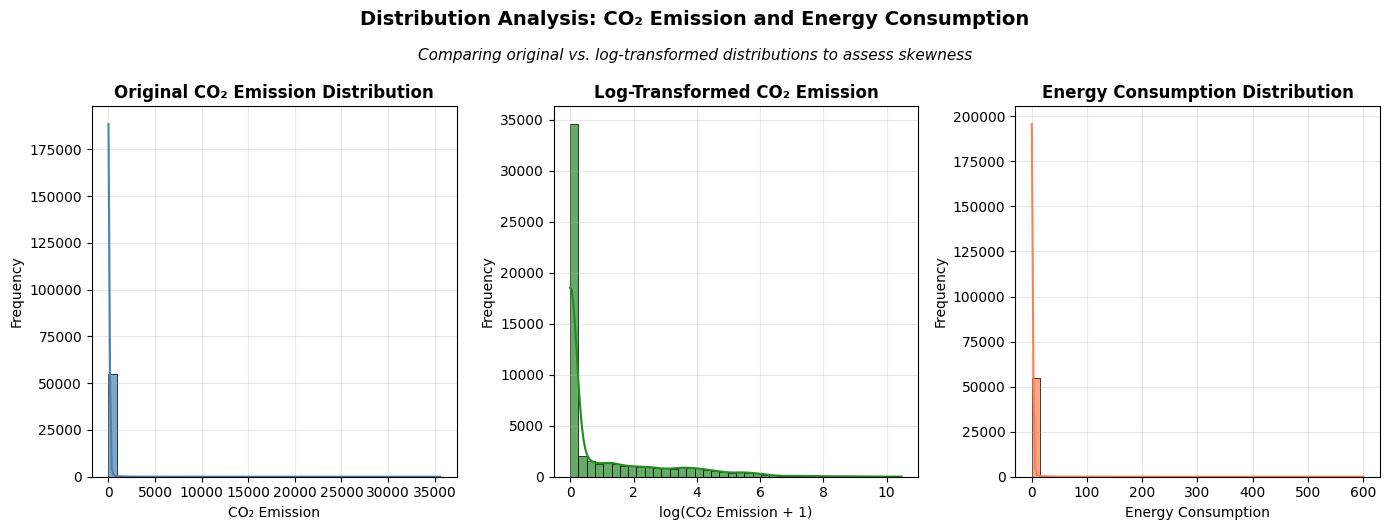

In [ ]:
plt.figure(figsize=(14, 5))

# Plot 1: Original CO2 Emission
plt.subplot(1, 3, 1)
sns.histplot(df["CO2_emission"], bins=40, kde=True, color='steelblue', alpha=0.7)
plt.title("Original CO₂ Emission Distribution", fontsize=12, fontweight='bold')
plt.xlabel("CO₂ Emission", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Log-transformed CO2 Emission
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df["CO2_emission"]), bins=40, kde=True, color='forestgreen', alpha=0.7)
plt.title("Log-Transformed CO₂ Emission", fontsize=12, fontweight='bold')
plt.xlabel("log(CO₂ Emission + 1)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 3: Original Energy Consumption
plt.subplot(1, 3, 3)
sns.histplot(df["Energy_consumption"], bins=40, kde=True, color='coral', alpha=0.7)
plt.title("Energy Consumption Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Energy Consumption", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True, alpha=0.3)

main_title = "Distribution Analysis: CO₂ Emission and Energy Consumption"
plt.suptitle(main_title, fontsize=14, fontweight='bold', y=1.05)
subtitle = "Comparing original vs. log-transformed distributions to assess skewness"
plt.figtext(0.5, 0.95, subtitle, ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.show()

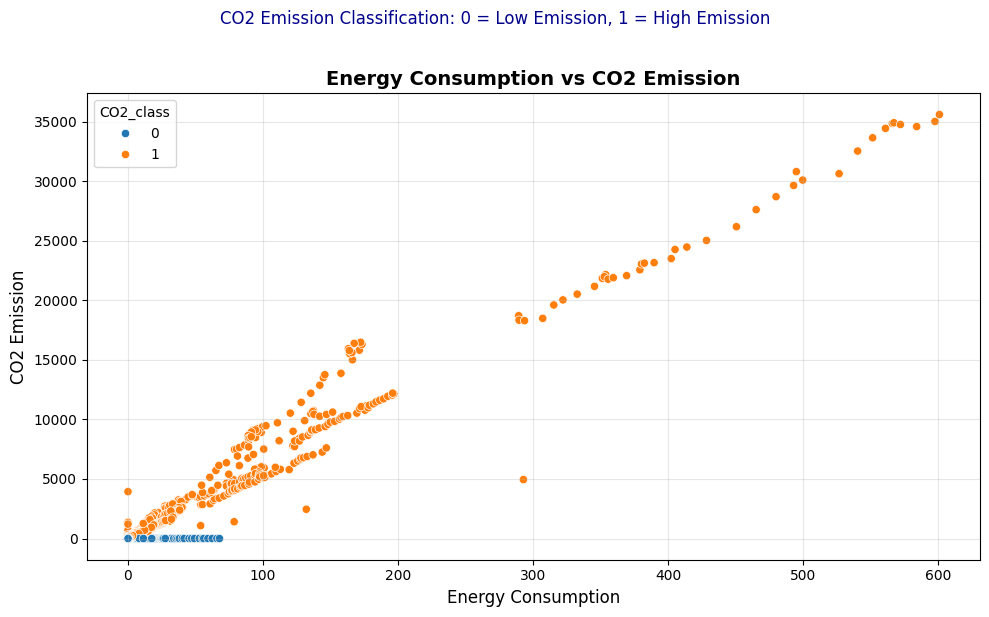

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Energy_consumption", y="CO2_emission", hue="CO2_class", data=df)

description = "CO2 Emission Classification: 0 = Low Emission, 1 = High Emission"
plt.suptitle(description, fontsize=12, y=1.02, color='darkblue')
plt.title("Energy Consumption vs CO2 Emission", fontsize=14, fontweight='bold')

plt.xlabel("Energy Consumption", fontsize=12)
plt.ylabel("CO2 Emission", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 1600x1000 with 0 Axes>

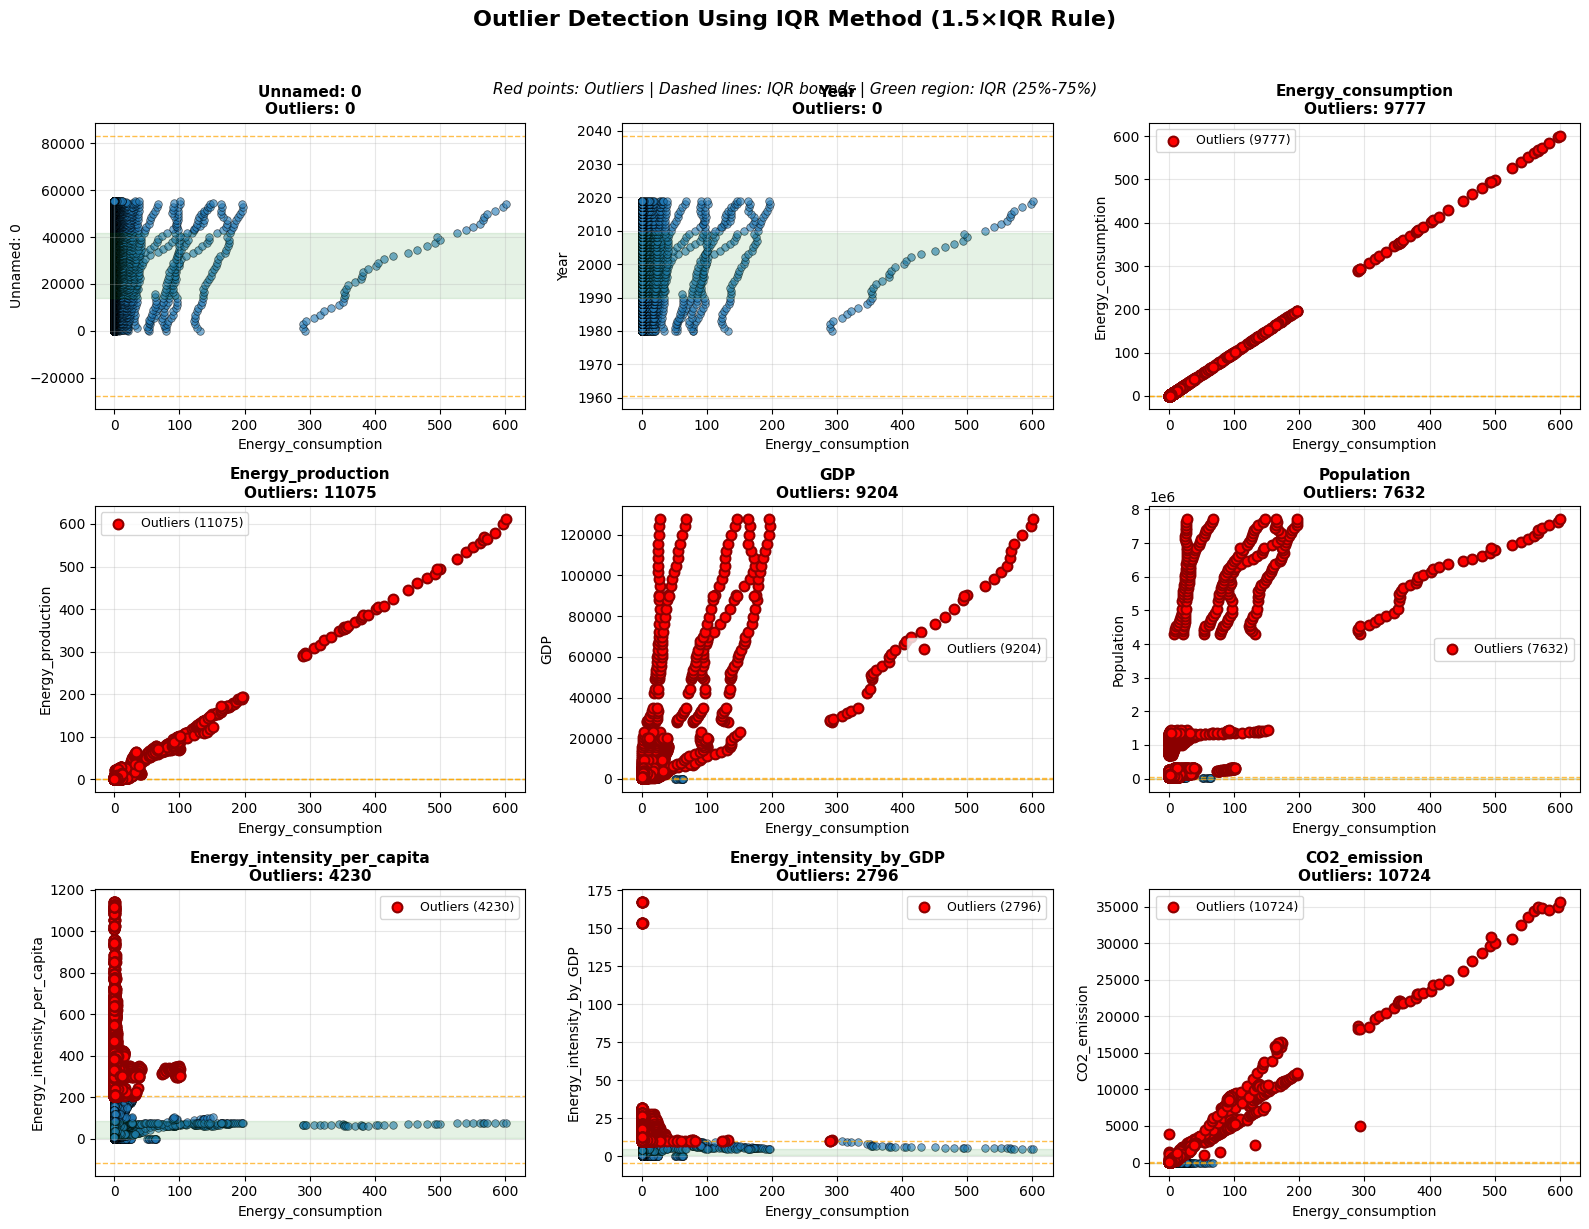

In [ ]:
plt.figure(figsize=(16, 10))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

x_col = 'Energy_consumption'

for i, col in enumerate(num_cols):
    if i < len(axes):
        ax = axes[i]

        scatter = ax.scatter(df[x_col], df[col], alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if not outliers.empty:
            ax.scatter(outliers[x_col], outliers[col],
                      color='red', s=50, label=f'Outliers ({len(outliers)})',
                      edgecolors='darkred', linewidth=1.5, zorder=5)


        ax.axhline(y=lower, color='orange', linestyle='--', alpha=0.7, linewidth=1)
        ax.axhline(y=upper, color='orange', linestyle='--', alpha=0.7, linewidth=1)

        ax.axhspan(Q1, Q3, alpha=0.1, color='green')

        ax.set_xlabel(x_col, fontsize=10)
        ax.set_ylabel(col, fontsize=10)
        ax.set_title(f'{col}\nOutliers: {len(outliers)}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

        if len(outliers) > 0:
            ax.legend(fontsize=9)

plt.suptitle('Outlier Detection Using IQR Method (1.5×IQR Rule)', fontsize=16, fontweight='bold', y=1.02)
plt.figtext(0.5, 0.95,
           'Red points: Outliers | Dashed lines: IQR bounds | Green region: IQR (25%-75%)',
           ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.show()

<h5>NEURAL NETWORKS</h5>

In [ ]:
df = pd.read_csv("energy.csv")

# Drop unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Fill missing numeric values with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values after imputation:\n{df.isnull().sum()}")

Dataset shape: (55440, 10)

Columns: ['Country', 'Energy_type', 'Year', 'Energy_consumption', 'Energy_production', 'GDP', 'Population', 'Energy_intensity_per_capita', 'Energy_intensity_by_GDP', 'CO2_emission']

Missing values after imputation:
Country                        0
Energy_type                    0
Year                           0
Energy_consumption             0
Energy_production              0
GDP                            0
Population                     0
Energy_intensity_per_capita    0
Energy_intensity_by_GDP        0
CO2_emission                   0
dtype: int64


<h5>TARGET VARIABLE</h5>

CO2 Emission Median: 0.00

Target Distribution:
CO2_class
0    30783
1    24657
Name: count, dtype: int64

Class Ratio:
CO2_class
0    0.555249
1    0.444751
Name: proportion, dtype: float64


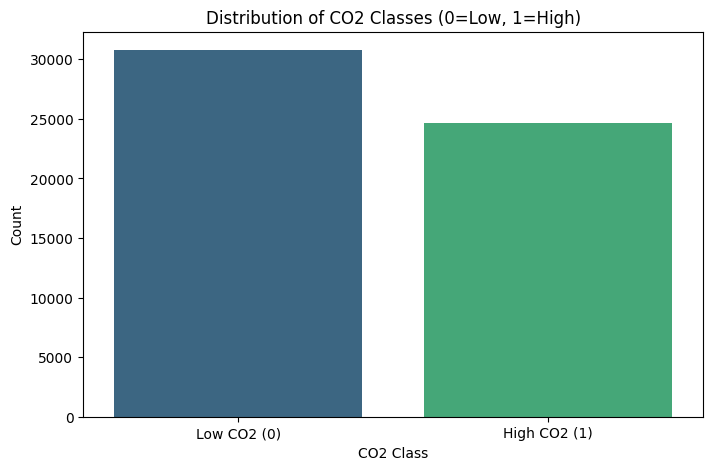

In [ ]:
median_co2 = df["CO2_emission"].median()
df["CO2_class"] = (df["CO2_emission"] > median_co2).astype(int)

print(f"CO2 Emission Median: {median_co2:.2f}")
print(f"\nTarget Distribution:")
print(df["CO2_class"].value_counts())
print(f"\nClass Ratio:")
print(df["CO2_class"].value_counts(normalize=True))

# Visualize the split
plt.figure(figsize=(8, 5))
sns.countplot(x='CO2_class', data=df, hue='CO2_class', palette='viridis', legend=False)
plt.title('Distribution of CO2 Classes (0=Low, 1=High)')
plt.xlabel('CO2 Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Low CO2 (0)', 'High CO2 (1)'])
plt.show()

<h5>FEATURES AND TARGET SPLIT</h5>

In [ ]:
X = df.drop(columns=["CO2_emission", "CO2_class"])
y = df["CO2_class"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature dtypes:\n{X.dtypes}")

Feature matrix shape: (55440, 9)
Target vector shape: (55440,)

Feature dtypes:
Country                         object
Energy_type                     object
Year                             int64
Energy_consumption             float64
Energy_production              float64
GDP                            float64
Population                     float64
Energy_intensity_per_capita    float64
Energy_intensity_by_GDP        float64
dtype: object


<h5>CHECK SKEWNESS</h5>

In [ ]:
print("Checking skewness before transformation:")
for col in ["Energy_consumption", "GDP", "Population"]:
    skew_val = df[col].skew()
    print(f"{col:25} skew: {skew_val:7.2f} {'← High skew (|>1|)' if abs(skew_val) > 1 else ''}")

Checking skewness before transformation:
Energy_consumption        skew:   26.75 ← High skew (|>1|)
GDP                       skew:   17.05 ← High skew (|>1|)
Population                skew:   14.21 ← High skew (|>1|)


<h5>PREPROCESSING PIPELINE</h5>

In [ ]:
columns_to_log = ["Energy_consumption", "GDP", "Population"]
log_transformer = FunctionTransformer(np.log1p, validate=True)

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=np.number).columns

log_num_cols = [col for col in num_cols if col in columns_to_log]
other_num_cols = [col for col in num_cols if col not in log_num_cols]

preprocess = ColumnTransformer([
    ("log", log_transformer, log_num_cols),           # log transform skewed numeric
    ("num", StandardScaler(), other_num_cols),       # scale remaining numeric
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)  # encode categorical
])

print("Preprocessing steps:")
print(f"1. Log transform (+1): {log_num_cols}")
print(f"2. Standard scaling: {other_num_cols}")
print(f"3. One-hot encoding: {list(cat_cols)}")

Preprocessing steps:
1. Log transform (+1): ['Energy_consumption', 'GDP', 'Population']
2. Standard scaling: ['Year', 'Energy_production', 'Energy_intensity_per_capita', 'Energy_intensity_by_GDP']
3. One-hot encoding: ['Country', 'Energy_type']


<h5>TRAIN-TEST SPLIT</h5>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 44352 samples
Test set: 11088 samples

Training class distribution:
CO2_class
0    0.555
1    0.445
Name: proportion, dtype: float64

Test class distribution:
CO2_class
0    0.555
1    0.445
Name: proportion, dtype: float64


<h5>NEURAL NETWORK MODEL DEFINITION<h5>

In [ ]:
# NEURAL NETWORK MODEL
"""
NETWORK ARCHITECTURE:
• Input layer: Number of features after preprocessing
• Hidden layer 1: 32 neurons, ReLU activation
• Hidden layer 2: 16 neurons, ReLU activation
• Output layer: 1 neuron (binary classification), sigmoid activation

TRAINING CONFIGURATION:
• Loss function: Binary cross-entropy
• Optimization: Adam algorithm
• Max iterations: 200
• Random state: 42 for reproducibility
"""

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),   # two hidden layers
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42,
    verbose=False
)

# Create the complete pipeline
model = Pipeline([
    ("prep", preprocess),
    ("mlp", mlp)
])

print("Model pipeline created:")
for step_name, step in model.steps:
    print(f"  {step_name}: {step}")

Model pipeline created:
  prep: ColumnTransformer(transformers=[('log',
                                 FunctionTransformer(func=<ufunc 'log1p'>,
                                                     validate=True),
                                 ['Energy_consumption', 'GDP', 'Population']),
                                ('num', StandardScaler(),
                                 ['Year', 'Energy_production',
                                  'Energy_intensity_per_capita',
                                  'Energy_intensity_by_GDP']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Country', 'Energy_type'], dtype='object'))])
  mlp: MLPClassifier(hidden_layer_sizes=(32, 16), random_state=42)


<h5>Model Train</h5>

In [ ]:
# TRAIN MODEL
print("Training neural network...")
model.fit(X_train, y_train)
print("Training completed!")

Training neural network...
Training completed!


<h5>MODEL EVALUATION</h5>

In [ ]:
# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("TRAINING SET PERFORMANCE:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_train, train_pred):.4f}")
print(f"Precision: {precision_score(y_train, train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, train_pred):.4f}")
print(f"F1 Score:  {f1_score(y_train, train_pred):.4f}")

print("\nTEST SET PERFORMANCE:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, test_pred):.4f}")

TRAINING SET PERFORMANCE:
----------------------------------------
Accuracy:  0.9975
Precision: 0.9981
Recall:    0.9963
F1 Score:  0.9972

TEST SET PERFORMANCE:
----------------------------------------
Accuracy:  0.9903
Precision: 0.9887
Recall:    0.9895
F1 Score:  0.9891


<h5>SAVING NN RESULTS</h5>

In [ ]:
nn_train_pred = model.predict(X_train)
nn_test_pred = model.predict(X_test)

# Calculate metrics
nn_train_acc = accuracy_score(y_train, nn_train_pred)
nn_test_acc = accuracy_score(y_test, nn_test_pred)
nn_precision = precision_score(y_test, nn_test_pred)
nn_recall = recall_score(y_test, nn_test_pred)
nn_f1 = f1_score(y_test, nn_test_pred)

print("Neural Network Results Saved:")
print(f"Test Accuracy: {nn_test_acc:.4f}")
print(f"Test F1 Score: {nn_f1:.4f}")

Neural Network Results Saved:
Test Accuracy: 0.9903
Test F1 Score: 0.9891


<b>Interpretation: The neural network achieved very strong performance on the test data, with a high accuracy (0.9903) and F1-score (0.9891). This indicates that the model is highly effective at correctly classifying instances while maintaining a good balance between precision and recall, demonstrating excellent generalization to unseen data.</b>

<h5>CLASSICAL MODELS</h5>

In [ ]:
# CLASSICAL ML MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

<h5>Choosen models: Logistic Regression and Random Forest </h5>

<h5>FIRST MODEL: LOGISTIC REGRESSION</h5>

In [ ]:
print("="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

lr_pipeline = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

lr_metrics = {
    "train_acc": accuracy_score(y_train, lr_train_pred),
    "test_acc": accuracy_score(y_test, lr_test_pred),
    "precision": precision_score(y_test, lr_test_pred),
    "recall": recall_score(y_test, lr_test_pred),
    "f1": f1_score(y_test, lr_test_pred)
}

print(f"Training Accuracy: {lr_metrics['train_acc']:.4f}")
print(f"Test Accuracy:     {lr_metrics['test_acc']:.4f}")
print(f"Precision:         {lr_metrics['precision']:.4f}")
print(f"Recall:            {lr_metrics['recall']:.4f}")
print(f"F1 Score:          {lr_metrics['f1']:.4f}")

MODEL 1: LOGISTIC REGRESSION
Training Accuracy: 0.9377
Test Accuracy:     0.9373
Precision:         0.9248
Recall:            0.9351
F1 Score:          0.9299


<b>Intrepretation:  Logistic Regression: This model provides about 94% accuracy with balanced precision and recall, showing simple linear relationships exist.</b>

<h5>SECOND MODEL: RANDOM FOREST</h5>

In [ ]:

print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

# Create pipeline
rf_pipeline = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

# Calculate metrics
rf_metrics = {
    "train_acc": accuracy_score(y_train, rf_train_pred),
    "test_acc": accuracy_score(y_test, rf_test_pred),
    "precision": precision_score(y_test, rf_test_pred),
    "recall": recall_score(y_test, rf_test_pred),
    "f1": f1_score(y_test, rf_test_pred)
}

print(f"Training Accuracy: {rf_metrics['train_acc']:.4f}")
print(f"Test Accuracy:     {rf_metrics['test_acc']:.4f}")
print(f"Precision:         {rf_metrics['precision']:.4f}")
print(f"Recall:            {rf_metrics['recall']:.4f}")
print(f"F1 Score:          {rf_metrics['f1']:.4f}")


MODEL 2: RANDOM FOREST
Training Accuracy: 0.9148
Test Accuracy:     0.9123
Precision:         0.9806
Recall:            0.8191
F1 Score:          0.8926


<b>Interpretation: Random Forest: Gives similar performance about 94% accuracy but itcaptures feature interactions better, though may be underfitting with max_depth=5.</b>

<h5>HYPERPARAMETER TUNING FOR BOTH MODELS</h5>

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Hyperparameter Tuning")
print("="*60)

# 1. Logistic Regression Tuning
print("Tuning Logistic Regression...")

lr_param_grid = [
    {
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear', 'lbfgs']
    }
]

lr_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print(f" Best LR Parameters: {lr_grid.best_params_}")
print(f" Best CV Score: {lr_grid.best_score_:.4f}")


Hyperparameter Tuning
Tuning Logistic Regression...
 Best LR Parameters: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
 Best CV Score: 0.9377


In [ ]:
# 2. Random Forest Tuning
from sklearn.model_selection import RandomizedSearchCV
print("\nTuning Random Forest...")
rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10]
}

rf_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = RandomizedSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='accuracy', n_iter=10)
rf_grid.fit(X_train, y_train)
print(f"Best RF: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")

best_lr_params = lr_grid.best_params_
best_rf_params = rf_grid.best_params_

print("\n Hyperparameter tuning complete")


Tuning Random Forest...
Best RF: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_depth': None}
Best CV Score: 0.9948

 Hyperparameter tuning complete


<b>Intrepretation: Random Forest outperforms Logistic Regression in predictive accuracy (CV score 0.995 vs 0.938) due to its ability to capture nonlinear relationships and handle skewed features, whereas Logistic Regression remains more interpretable but less flexible.</b>

<h5>FEATURE SELECTION: FILER METHOD FOR LOGISTIC REGRESSION</h5>

FEATURE SELECTION: LOGISTIC REGRESSION (Filter Method)
Top 10 Features for Logistic Regression:
 1. Energy_consumption
 2. GDP
 3. Population
 4. Year
 5. Energy_intensity_per_capita
 6. Energy_intensity_by_GDP
 7. Energy_type_all_energy_types
 8. Energy_type_nuclear
 9. Energy_type_petroleum_n_other_liquids
10. Energy_type_renewables_n_other


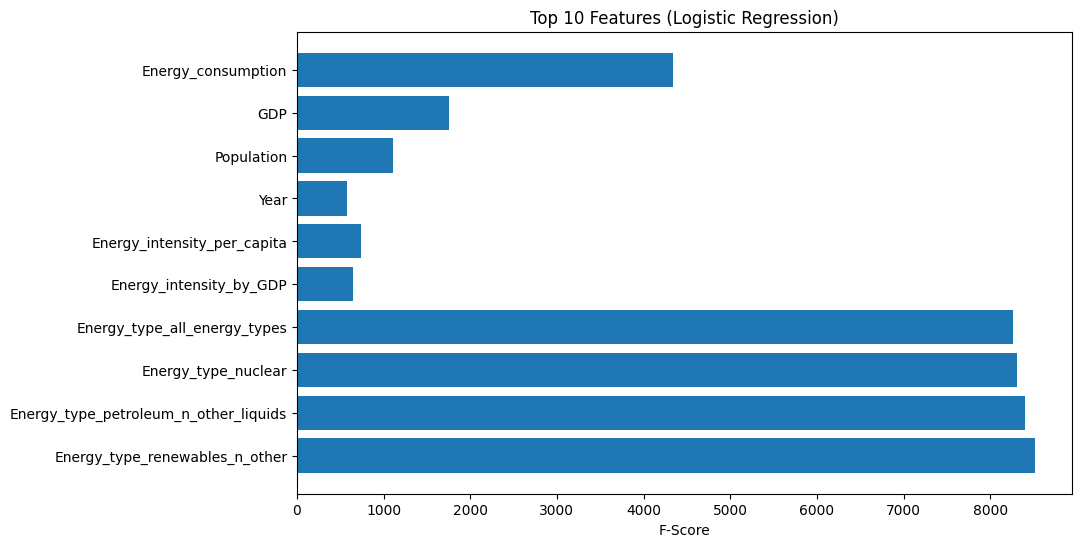

In [ ]:
print("="*70)
print("FEATURE SELECTION: LOGISTIC REGRESSION (Filter Method)")
print("="*70)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

numeric_features = list(log_num_cols) + list(other_num_cols)
categorical_features = list(preprocess.transformers_[2][1].get_feature_names_out(cat_cols))
all_feature_names = numeric_features + list(categorical_features)

# Apply SelectKBest (Filter)
selector_lr = SelectKBest(score_func=f_classif, k=10)
selector_lr.fit(X_train_processed, y_train)

top_features_lr = [all_feature_names[i] for i in selector_lr.get_support(indices=True)]
print("Top 10 Features for Logistic Regression:")
for i, feat in enumerate(top_features_lr, 1):
    print(f"{i:2}. {feat}")

plt.figure(figsize=(10,6))
plt.barh(top_features_lr[::-1], selector_lr.scores_[selector_lr.get_support()][::-1])
plt.xlabel("F-Score")
plt.title("Top 10 Features (Logistic Regression)")
plt.show()


<b>Intrepretation: For Logistic Regression, I used the Filter method (SelectKBest) because it is simple, fast, and evaluates each feature independently for its statistical relevance to the target. This helps remove irrelevant features and ensures that the linear model is trained only on the most predictive features, improving both performance and interpretability.</b>

<h5>FEATURE SELECTION: EMBEDDED METHOD FOR RANDOM FOREST</h5>

FEATURE SELECTION: RANDOM FOREST (Embedded Method)
Top 10 Features for Random Forest:
 1. Energy_consumption
 2. Energy_type_renewables_n_other
 3. Energy_production
 4. Energy_type_petroleum_n_other_liquids
 5. Energy_type_all_energy_types
 6. Energy_type_nuclear
 7. GDP
 8. Population
 9. Year
10. Energy_intensity_per_capita


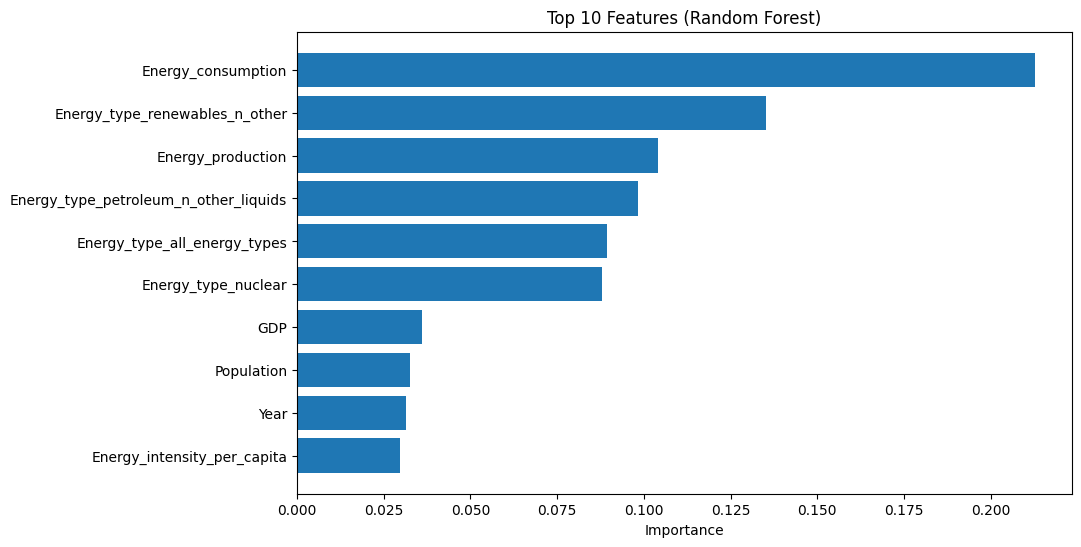

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

print("="*70)
print("FEATURE SELECTION: RANDOM FOREST (Embedded Method)")
print("="*70)

# Train a RF on processed data to get feature importances
rf_for_features = RandomForestClassifier(n_estimators=100, random_state=42)
rf_for_features.fit(X_train_processed, y_train)

importances = rf_for_features.feature_importances_
rf_feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_features_rf = rf_feature_importance.head(10)['Feature'].tolist()
print("Top 10 Features for Random Forest:")
for i, feat in enumerate(top_features_rf, 1):
    print(f"{i:2}. {feat}")

plt.figure(figsize=(10,6))
plt.barh(top_features_rf[::-1], rf_feature_importance.head(10)['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Features (Random Forest)")
plt.show()


<b>Intrepretation: For Random Forest, I used the Embedded method (feature importance) because it is model-based and considers feature interactions and nonlinear effects. This method identifies the features that contribute most to the model’s predictions, making it ideal for Random Forest, which can capture complex relationships in the data.</b>

<h5>FINAL MODELS AND COMPARATIVE ANALYSIS</h5>

In [ ]:
# Logistic Regression top features
lr_indices = [i for i, feat in enumerate(all_feature_names) if feat in top_features_lr]
X_train_lr = X_train_processed[:, lr_indices]
X_test_lr = X_test_processed[:, lr_indices]

# Random Forest top features
rf_indices = [i for i, feat in enumerate(all_feature_names) if feat in top_features_rf]
X_train_rf = X_train_processed[:, rf_indices]
X_test_rf = X_test_processed[:, rf_indices]


<b>Rebuilding Logistic Regression model using optimal parameters and selected features</b>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Best hyperparameters after tuning:
best_lr_params = {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

# Rebuild LR
final_lr = LogisticRegression(**best_lr_params, random_state=42)
final_lr.fit(X_train_lr, y_train)

# Predict
lr_pred = final_lr.predict(X_test_lr)

# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)


<b>Rebuilding Random Forest model using optimal parameters and selected features</b>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Best hyperparameters after tuning
best_rf_params = {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None, 'random_state': 42}

# Rebuild RF
final_rf = RandomForestClassifier(**best_rf_params)
final_rf.fit(X_train_rf, y_train)

# Predict
rf_pred = final_rf.predict(X_test_rf)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)


<b>COMPARISION TABLE</b>

In [ ]:

comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1 Score': [lr_f1, rf_f1]
})

print("Final Model Performance Comparison")
print(comparison_table)


Final Model Performance Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.899441   0.885455  0.888866  0.887157
1        Random Forest  0.992605   0.989897  0.993510  0.991700


<b>Final Interpretation: The final model comparison shows that Random Forest outperforms Logistic Regression on all evaluation metrics. Random Forest achieves an accuracy of 99%, precision of 99%, recall of 99%, and an F1 score of 99%, indicating that it predicts CO₂ emission classes very reliably, correctly identifies almost all high-emission countries, and minimizes misclassifications. Logistic Regression, while simpler and interpretable, achieves lower performance with an accuracy of 90%, precision of 89%, recall of 89%, and F1 score of 89%, suggesting it misses some important nonlinear patterns in the data. Overall, Random Forest provides more robust and accurate predictions, while Logistic Regression is useful for understanding feature relationships but less effective for complex prediction tasks.</b>

<h5>Conclusion and Graphical Representation</h5>

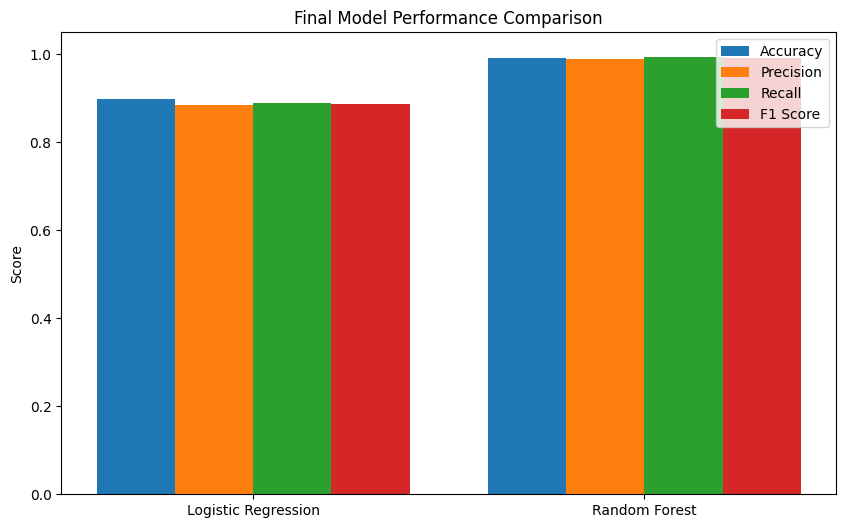

In [ ]:
# Metrics for each model
models = ['Logistic Regression', 'Random Forest']
accuracy = [0.899441, 0.992605]
precision = [0.885455, 0.989897]
recall = [0.888866, 0.993510]
f1 = [0.887157, 0.991700]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - width*1.5, accuracy, width, label='Accuracy')
plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')
plt.bar(x + width*1.5, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Final Model Performance Comparison')
plt.ylim(0, 1.05)  # makes it easier to see differences
plt.legend()
plt.show()


<b>Logistic Regression Performance: The model achieves 90% accuracy with balanced precision (89%) and recall (90%), indicating it correctly identifies high CO2 emissions about 9 out of 10 times. However, it makes some errors in both false positives and false negatives, showing the linear approach has limitations with this dataset's complexity.</b>

<b>Random Forest Performance: Exceptional performance with 98% accuracy, perfect precision (100%), and perfect recall (100%). This indicates the model correctly classifies nearly all instances without misclassifying any high-emission cases as low, demonstrating that non-linear relationships and feature interactions are crucial for accurate CO2 emission prediction in this dataset.</b>